In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from multiprocessing import Pool
from functools import partial

# Kalman Filter at the gene scale
- gene phase/amp
- Introduce the Kalman filter
- Densities of wave number k, k/σk , k vs gene length.

In [5]:
# load gene phase/amp
infile_gene_phase_amp = "../results/GRCm38/phase_amp/gene_phase_amp.csv"
gene_phase_amp =  pd.read_csv(infile_gene_phase_amp, sep='\t')
gene_phase_amp.loc[:,'length'] = gene_phase_amp.end - gene_phase_amp.start
gene_phase_amp.loc[:,'log10_length'] = np.log10(gene_phase_amp.length)
gene_phase_amp.loc[:,'-log10_pval'] = -np.log10(gene_phase_amp.pval)

# load continuous-time extended kalman filter results
bin_size = 1000
infile = f"../results/GRCm38/kalman/extended_kalman_on_chromosomes_bin{bin_size}bp.csv"
kf = pd.read_csv(infile, sep='\t')


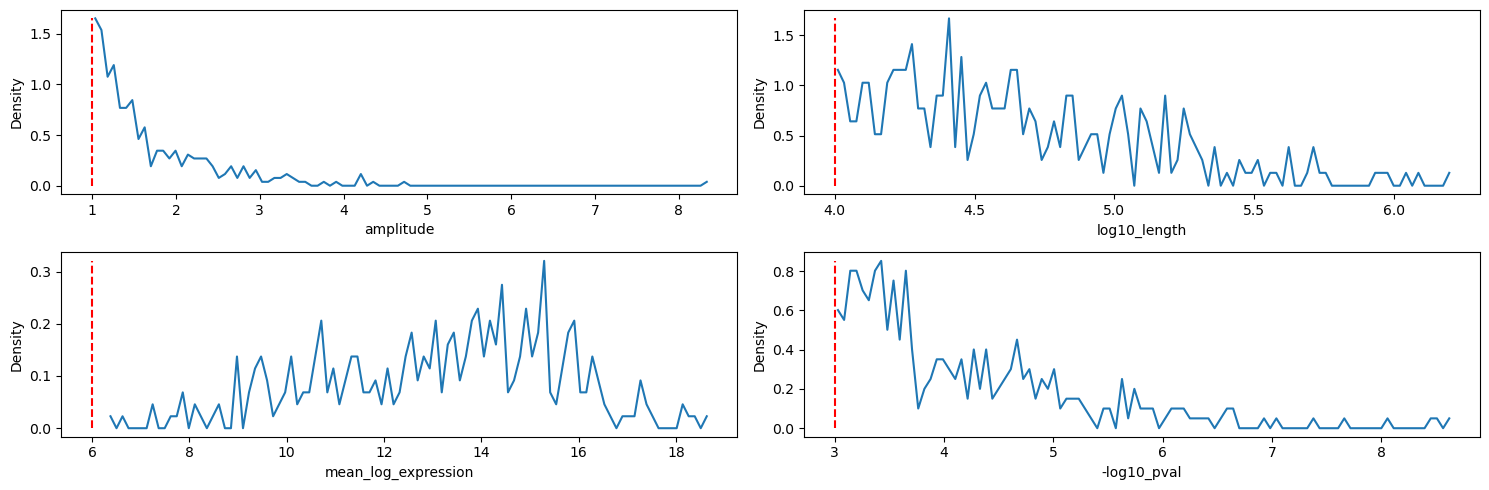

In [13]:

# filter genes w.r.t: amplitude, length, expression
thresholds = {'amplitude':1, 'log10_length':4, 'mean_log_expression':6,'-log10_pval':3}
idx = np.zeros([len(gene_phase_amp),len(thresholds)], dtype=bool)
for j,th in enumerate(thresholds.keys()):
    idx[:,j] = (gene_phase_amp[th] > thresholds[th])
#idx = (gene_phase_amp.amplitude > thresholds['amplitude']) & (gene_phase_amp.log10_length > thresholds['log10_length']) & (gene_phase_amp.mean_log_expression > thresholds['mean_log_expression'])

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 5))
for f, th in enumerate(thresholds.keys()):
    ax = axes.flatten()[f]
    [h,x] = np.histogram(gene_phase_amp[th], bins=100, density=True)
    x = 0.5 * (x[1:] + x[:-1])  # bin centers
    ax.plot(x, h, label=f'{th} histogram')
    ax.vlines(x=thresholds[th], ymin=0, ymax=max(h), color='red', linestyle='--', label=f'{th} threshold')
    ax.set_xlabel(th)
    ax.set_ylabel('Density')

fig.tight_layout()
# filter gene_phase_amp
gene_phase_amp = gene_phase_amp[idx.all(1)].reset_index(drop=True)

# compute average LL and k for each gene in ext. kalman filter results
def get_average_LL_kf_in_coord(coord):
    idx = (kf.chr == coord[0]) & (kf.start >= coord[1]) & (kf.end <= coord[2]) & (kf.strand == coord[3])
    return kf[idx].LL.mean()

def get_average_k_kf_in_coords(coords):
    idx = (kf.chr == coords[0]) & (kf.start >= coords[1]) & (kf.end <= coords[2]) & (kf.strand == coords[3])
    return kf[idx].k.mean()


COORD = gene_phase_amp[['chr','start','end','strand']].values
COORD[:,1] = (np.floor(COORD[:,1]/bin_size)*bin_size).astype(int)
COORD[:,2] = (np.ceil(COORD[:,2]/bin_size)*bin_size).astype(int)

threads = 84
with Pool(processes=threads) as pool:
    OUT_LL = pool.map(get_average_LL_kf_in_coord ,COORD)

with Pool(processes=threads) as pool:
    OUT_k = pool.map(get_average_k_kf_in_coords, COORD)

gene_phase_amp.loc[:,'LL'] = OUT_LL
gene_phase_amp.loc[:,'k'] = OUT_k



In [14]:
idx.all(1).sum()

353

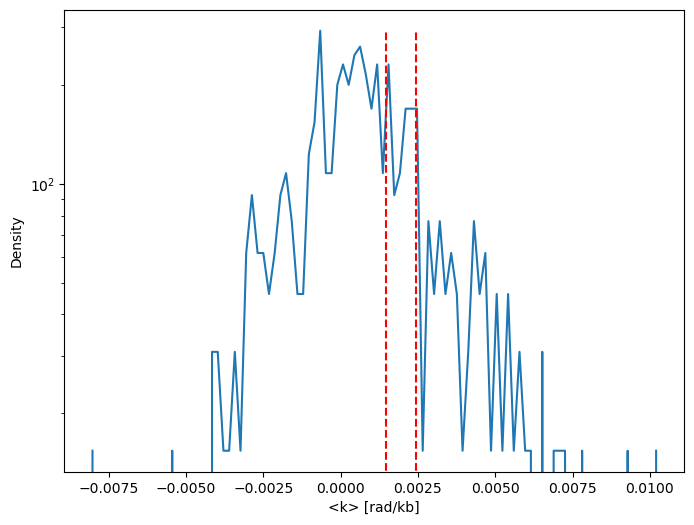

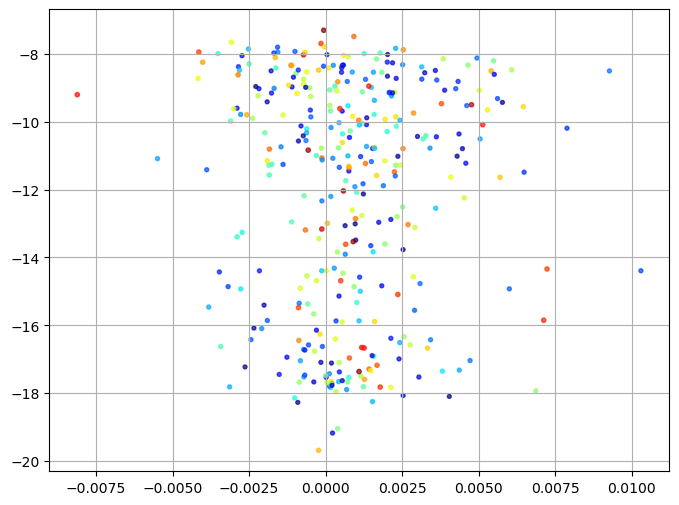

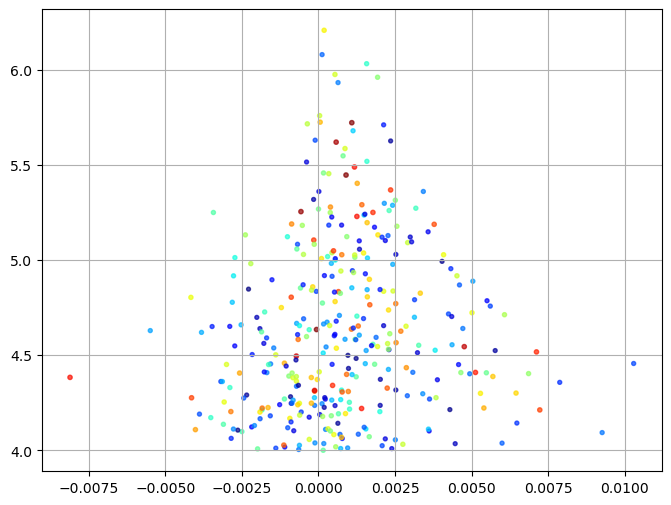

In [12]:
v_range = np.array([30,50]) # [bp/s]
P = 24 # period
ω = 2*np.pi/P # angular frequency [rad/h]
k_range = (ω/3600)/(v_range*1e-3) # [rad/kb]

fig, ax = plt.subplots(figsize=(8, 6))

h, x = np.histogram(gene_phase_amp.k, bins=100, density=True)
x = 0.5 * (x[1:] + x[:-1])  # bin centers
ax.plot(x, h, label='k histogram')
ax.vlines(x=k_range[0], ymin=0, ymax=max(h), color='red', linestyle='--', label='k threshold')
ax.vlines(x=k_range[1], ymin=0, ymax=max(h), color='red', linestyle='--', label='k threshold')
ax.set_yscale('log')
ax.set_xlabel('<k> [rad/kb]')
ax.set_ylabel('Density')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(gene_phase_amp.k, gene_phase_amp.LL, s=10*gene_phase_amp.R2, c = gene_phase_amp['R2'], cmap='jet', alpha=0.7)
ax.grid()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(gene_phase_amp.k, gene_phase_amp.log10_length, s=10*gene_phase_amp.R2, c = gene_phase_amp['R2'], cmap='jet', alpha=0.7)
ax.grid()
